In [1]:
import pandas as pd
import pickle as pkl
import os
import numpy as np

In [2]:
# Let's adjust the broadcasting to handle the matrix dimensions correctly during normalization
def att_score(A):
    """
    Process an attention matrix A according to the described steps.
    
    Args:
    A (numpy.ndarray): Input matrix of shape (no_layers * no_heads, L, L).
    
    Returns:
    numpy.ndarray: The final attention vector of length L.
    """
    
    # Step 1: Make the matrix symmetric by adding its transpose
    if A.ndim < 3:
        A = np.expand_dims(A, axis=0)
    A_symmetric = A + A.transpose(0, 2, 1)
    
    # Step 2: Normalize the symmetric matrix
    sum_i = np.sum(A_symmetric, axis=1)  # Sum across rows
    sum_j = np.sum(A_symmetric, axis=2)  # Sum across columns
    sum_total = np.sum(A_symmetric)  # Sum of all elements
    
    # Compute the average value broadcast across elements
    avg_value = (sum_i[:, :, None] @ sum_j[:, None, :]) / sum_total  # Reshaping for broadcasting
    A_normalized = A_symmetric - avg_value  # Element-wise subtraction
    
    # Step 3: Sum along the no_layers * no_heads dimension
    A_reduced = np.sum(A_normalized, axis=0)
    
    # Step 4: Sum along the rows to generate the final attention vector
    attention_vector = np.sum(A_reduced, axis=0)
    
    return attention_vector

In [3]:
def get_gene_att_score(res_dir, data_name):
    
    with open(os.path.join(res_dir, f"{data_name}_crossatt.pkl"), 'rb') as f: 
        cross_att_all = pkl.load(f)
    with open(os.path.join(res_dir, f"{data_name}_transformeratt.pkl"), 'rb') as f: 
        trans_att_all = pkl.load(f)

    cross_att_vec = []
    for att_part in range(4):
        att_folds = []
        for fold in range(len(cross_att_all[0])):
            att = cross_att_all[att_part][fold][0,:].squeeze()
            att_folds.append(att)
        att_avg = np.mean(np.stack(att_folds), axis=0)
        cross_att_vec.append(att_score(att_avg))
    
    trans_att_vec = []
    for att_part in range(2):
        att_folds = []
        for fold in range(len(trans_att_all[0])):
            att = trans_att_all[att_part][fold][0,:].squeeze()
            att_folds.append(att)
        att_avg = np.mean(np.stack(att_folds), axis=0)
        trans_att_vec.append(att_score(att_avg))

    return cross_att_vec, trans_att_vec

In [4]:
import yaml
import easydict
import json

# with open("../config/get_att.yaml", 'r') as f:
with open("../config/get_att_50.yaml", 'r') as f:
    config = easydict.EasyDict(yaml.safe_load(f))

In [5]:
def get_PRKDC_ranks():
    all_ranks = {}
    res_dir = "/home/jienihu/sc/SLformer/experiment/inference/IDH1_DDR_Glioma_test/idh1_inference_params"
    for i in range(70):
        res = pd.read_csv(os.path.join(res_dir, f"model_no_{i}_reactome.csv"))
        all_ranks[i] = res[res['partner_gene']=='PRKDC']['score'].item()
    
    return all_ranks

In [7]:
prkdc_ranks = get_PRKDC_ranks()
model_ranks = np.argsort(list(prkdc_ranks.values()))[::-1]

In [8]:
model_ranks

array([29, 34, 14, 30, 15, 64, 51, 60, 27, 66, 59, 12, 35,  9, 26, 13, 22,
       67, 53, 31,  0, 41, 39, 17, 25, 56, 40, 69, 55, 48, 43, 10, 54,  1,
       50,  4,  7, 45, 42, 52, 33, 63, 61, 57, 21, 65, 28, 68, 32, 47, 37,
        8, 62, 23, 20, 58, 44,  3, 46, 19, 38, 36, 18, 16, 11,  2,  6, 24,
        5, 49])

In [59]:
# res_dir = "/home/jienihu/sc/SLformer/experiment/att/IDH1_PRKDC_att"
# res_dir = "/home/jienihu/sc/SLformer/experiment/att/IDH1_PRKDC_att_50"
CANCER='LUAD'
res_dir = f"/home/jienihu/sc/SLformer/experiment/att/BRCA_PARP_att_50_{CANCER}"

sent_len=50 ## specified sentence length
base_dir = "/home/jienihu/sc/SLformer"

# cross_att_all = np.zeros((4, sent_len))
# trans_att_all = np.zeros((2, sent_len))
cross_att_all = []
trans_att_all = []
model_counts = 0

# for i in range(70):
for i in range(24):
    name = f"model_no_{i}"
    # name = f"model_no_{model_ranks[i]}"
    ## check if sent len is correct
    # with open(os.path.join(base_dir + config.task.model[name][1:], 'params.json'), 'r') as f:
    with open(os.path.join(base_dir + '/' + config.task.model[name], 'params.json'), 'r') as f:
        model_params = json.load(f)
    if model_params["n"] == sent_len:
        cross_att_vec, trans_att_vec = get_gene_att_score(res_dir, name)
        # cross_att_all += np.vstack(cross_att_vec)
        # trans_att_all += np.vstack(trans_att_vec)
        cross_att_all.append(np.vstack(cross_att_vec))
        trans_att_all.append(np.vstack(trans_att_vec))
        model_counts += 1

In [60]:
print(model_counts)
# cross_att_all = cross_att_all/model_counts
# trans_att_all = trans_att_all/model_counts

24


In [61]:
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2sent_n200_notransform.pkl", 'rb') as f: 
    gene2sent_map = pkl.load(f)
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2id.pkl", 'rb') as f: 
    gene2id_map = pkl.load(f)

id2gene_map = {i:g for g,i in gene2id_map.items()}
id2gene_map[-1]="pad"

def get_gene_sent(g_name, cancer=8, n=60):
    g_id = gene2id_map[g_name]
    ## Glioma cancer idx = 8
    g_sent_idx = gene2sent_map[cancer][g_id]
    g_sent = [id2gene_map[g-1] for g in g_sent_idx][:n]

    return g_sent

In [49]:
gene_sent_geneB = get_gene_sent("PRKDC", n=sent_len)
print(gene_sent_geneB)
gene_sent_geneA = get_gene_sent("IDH1", n=sent_len)
print(gene_sent_geneA)

['PRKDC', 'LIMA1', 'IGFBP2', 'TRAF4', 'PTN', 'FABP7', 'SEMA5A', 'TYMS', 'LAPTM4B', 'PRDX4', 'HMGA1', 'GGH', 'CENPV', 'TRIO', 'YBX1', 'CDK4', 'LMO4', 'ARL4A', 'HIST1H4C', 'SLC35F1', 'SLC35B1', 'COL9A3', 'UBE2S', 'MAD2L2', 'MMP16', 'RBP1', 'TMSB15A', 'TUBB2A', 'RPA3', 'CXADR', 'TSPAN13', 'DSEL', 'PXMP2', 'SMC4', 'MRPL12', 'BMP7', 'SEC11C', 'HNRNPD', 'TUBB2B', 'PALLD', 'SMC2', 'PLLP', 'FABP5', 'MAN1A2', 'CNN3', 'GADD45A', 'CCDC167', 'OCIAD2', 'CENPF', 'CENPH']
['IDH1', 'FABP7', 'FABP5', 'RBP1', 'PTN', 'ITM2A', 'KCNIP1', 'TM4SF1', 'MT1M', 'IGFBP2', 'DBI', 'TRAF4', 'SLC35F1', 'MT1E', 'MT1F', 'CHL1', 'CSPG5', 'TUBB2B', 'CENPV', 'GAPDH', 'LIMA1', 'OCIAD2', 'TRIO', 'PDGFRA', 'SEC11C', 'ISG15', 'EMP2', 'UCHL1', 'PLLP', 'LYPD1', 'ARC', 'TIMP1', 'CTHRC1', 'TUBB2A', 'IFI6', 'CCDC167', 'EPN2', 'CCND1', 'CXADR', 'SEMA5A', 'DMRT2', 'SNX10', 'MYO10', 'NKAPL', 'TPM2', 'TSPAN7', 'RPS26', 'SCN9A', 'TMSB15A', 'TUBA1A']


In [50]:
with open("/home/jienihu/sc/SLformer/data/saved_data/map/cancer_list.txt") as f:
    cancer_list = [line.rstrip('\n') for line in f]
cancer2id_map = {cancer:i for i,cancer in enumerate(cancer_list)}

In [63]:
cancer_id = cancer2id_map[CANCER]
gene_sent_geneB = get_gene_sent("PARP1", cancer=cancer_id, n=sent_len)
print(gene_sent_geneB)
gene_sent_geneA = get_gene_sent("BRCA2", cancer=cancer_id, n=sent_len)
print(gene_sent_geneA)

['PARP1', 'TXNRD1', 'CCT6A', 'UCHL1', 'MDH2', 'KPNB1', 'ILF2', 'CBX3', 'CYC1', 'PRKDC', 'ODC1', 'SET', 'GGCT', 'PAICS', 'CKS1B', 'LAPTM4B', 'DPYSL3', 'PDIA6', 'CCT5', 'RANBP1', 'EIF3B', 'STMN1', 'DEK', 'TARS', 'TMEM106C', 'VCP', 'HNRNPA3', 'CDK2AP1', 'PABPC1', 'SERBP1', 'PGD', 'DKC1', 'NCL', 'HSP90B1', 'UBE2D2', 'TCP1', 'MTHFD2', 'SLC25A39', 'GARS', 'XRCC5', 'FAM91A1', 'SNRPF', 'PPP1CC', 'HNRNPM', 'MCM7', 'YWHAG', 'ENO1', 'CNOT7', 'GPI', 'CYCS']


KeyError: 8402

In [9]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [21]:
def plot_att_vec(vec):

    if vec.shape[0] == 4:
        y_tick = ["att11", "att22", "att12", "att21"]
    elif vec.shape[0] == 2:
        y_tick = ["att1", "att2"]

    plt.rcParams.update({'font.size': 8})
    fig_width = 6 if vec.shape[0]==4 else 3
    fig, axs = plt.subplots(vec.shape[0], 1, figsize = (15, fig_width))
    fig.set_dpi(300)
    fig.tight_layout(pad=3.0)

    for i in range(vec.shape[0]):
        if  i==0 or i==3:
            x_tick = gene_sent_geneA
        elif i==1 or i==2:
            x_tick = gene_sent_geneB

        sns.heatmap(vec[i,:].reshape(1,-1), ax=axs[i], square=True, cmap="OrRd", cbar=False, xticklabels=x_tick)
        norm_unsoftmax = mpl.colors.Normalize(vmin = np.min(vec),
                                            vmax = np.max(vec))
        cbar_unsoftmax = fig.colorbar(mpl.cm.ScalarMappable(norm = norm_unsoftmax, cmap="OrRd"),
                                    orientation = 'vertical', ax = axs[i])
        cbar_unsoftmax.outline.set_visible(False)

        axs[i].set_xticklabels(x_tick, rotation=45)
        axs[i].set_ylabel(y_tick[i])

    if vec.shape[0] == 4:   
        fig.suptitle("cross attention scores")
    elif vec.shape[0] == 2:   
        fig.suptitle("transformer attention scores")

In [17]:
# plot_att_vec(np.vstack(cross_att_vec))
plot_att_vec(cross_att_all)

AttributeError: 'list' object has no attribute 'shape'

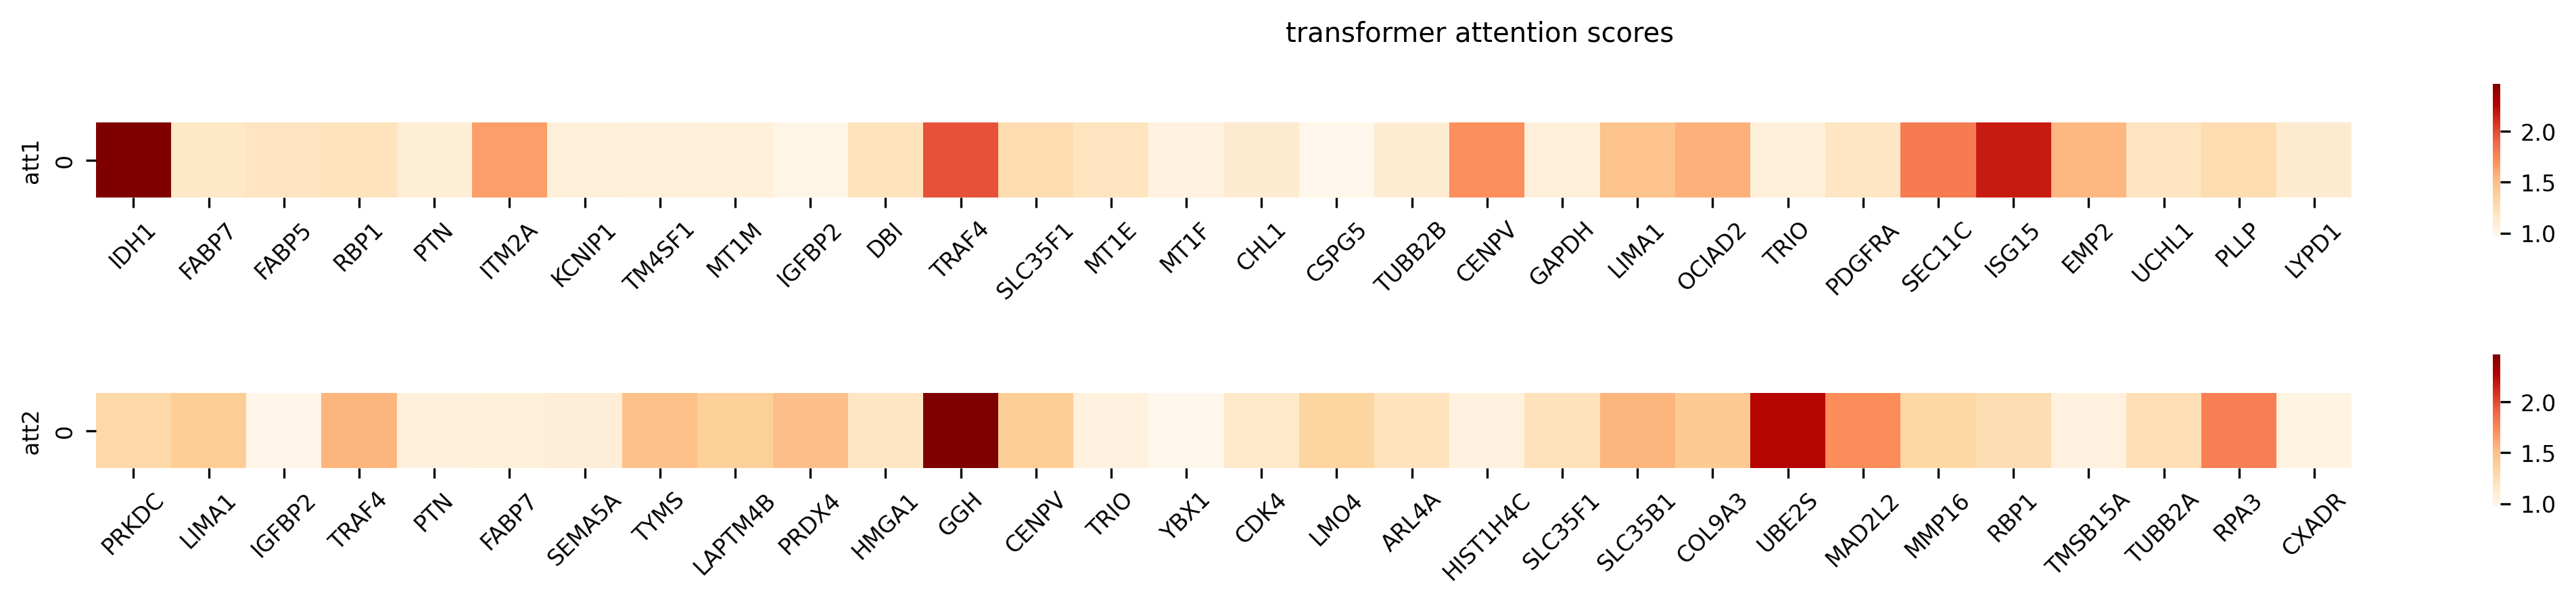

In [30]:
plot_att_vec(trans_att_all)

plot distributions

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [12]:
def plot_att_boxplot(array_list):
    """
    Plots a grid of box plots for a list of (r, c)-shaped arrays.
    
    Parameters:
        array_list (List[np.ndarray]): A list of n arrays, each of shape (r, c).
    """
    n = len(array_list)
    r, c = array_list[0].shape

    # Prepare DataFrame for seaborn
    data_records = []
    for idx, arr in enumerate(array_list):
        for i in range(r):
            for j in range(c):
                data_records.append({
                    'row': i,
                    'col': j,
                    'value': arr[i, j],
                    'index': idx  # optional identifier
                })

    df = pd.DataFrame(data_records)

    # Create shared-y-axis subplot grid
    fig, axs = plt.subplots(r, c, figsize=(2 * c, 6 * r), sharey=True, squeeze=False)

    for i in range(r):
        if  i==0 or i==3:
            genes = gene_sent_geneA
        elif i==1 or i==2:
            genes = gene_sent_geneB

        for j in range(c):
            ax = axs[i, j]
            subset = df[(df['row'] == i) & (df['col'] == j)]
            sns.boxplot(data=subset, x='col', y='value', ax=ax)
            ax.set_xlabel('')
            ax.set_xticks([])
            ax.set_title(genes[j], fontsize=15)
    
    if r==4:
        y_tick = ["att11", "att22", "att12", "att21"]
    elif r==2:
        y_tick = ["att1", "att2"]
    for i in range(r):
        axs[i,0].set_ylabel(y_tick[i], fontsize=15)

    plt.tight_layout()
    plt.show()

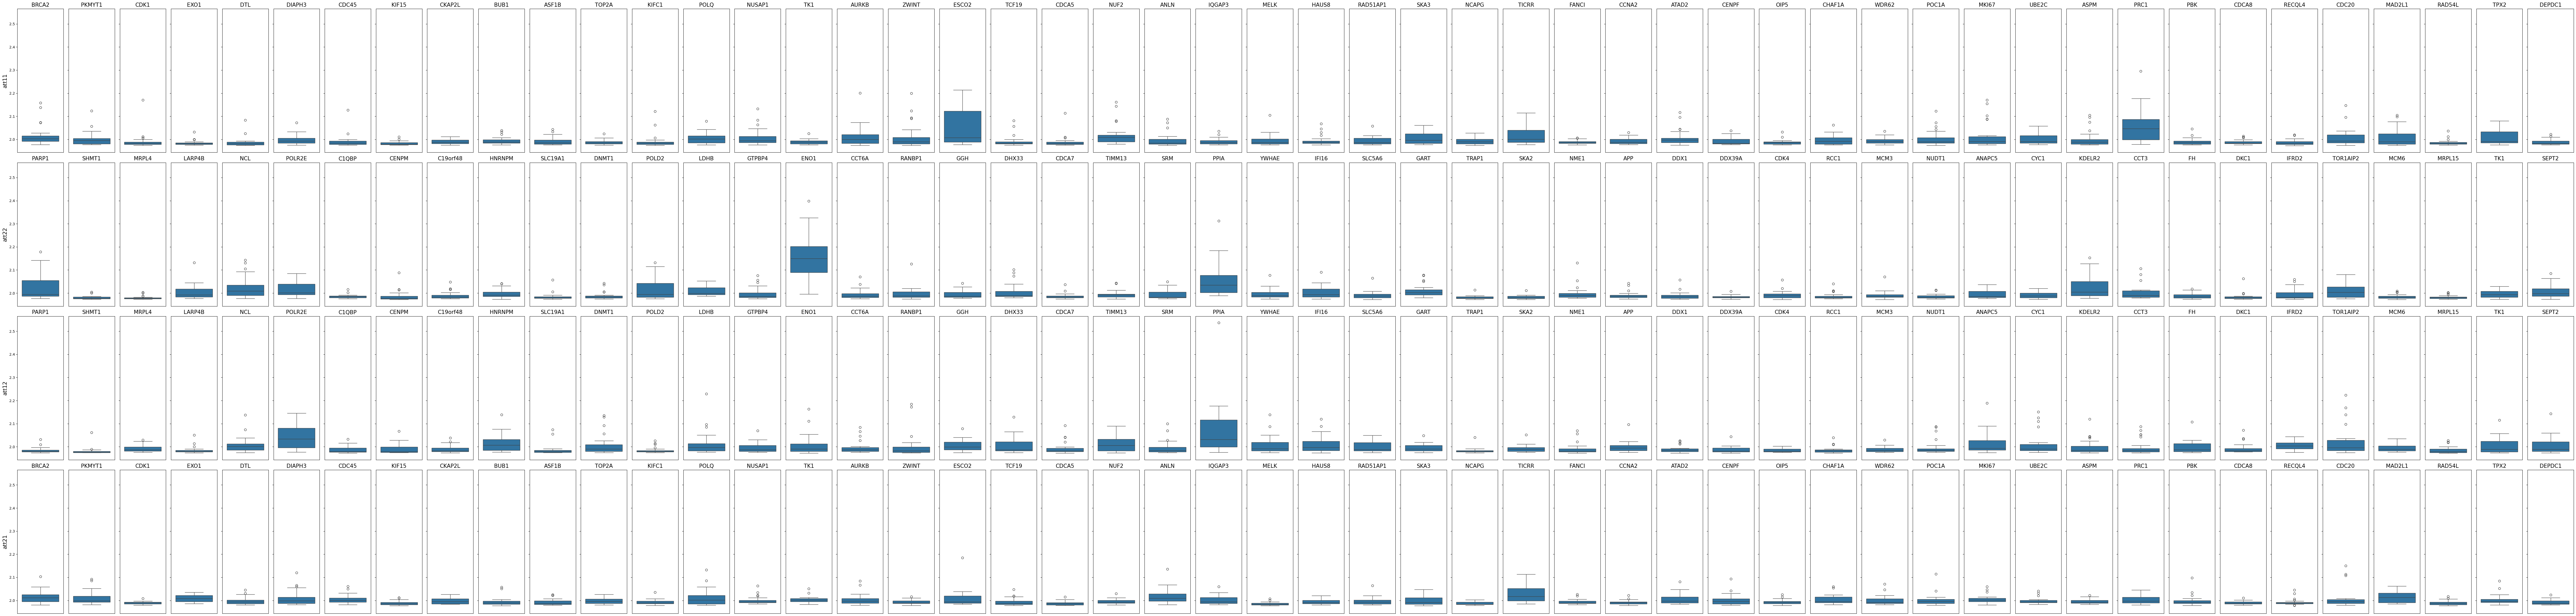

In [57]:
plot_att_boxplot(cross_att_all)

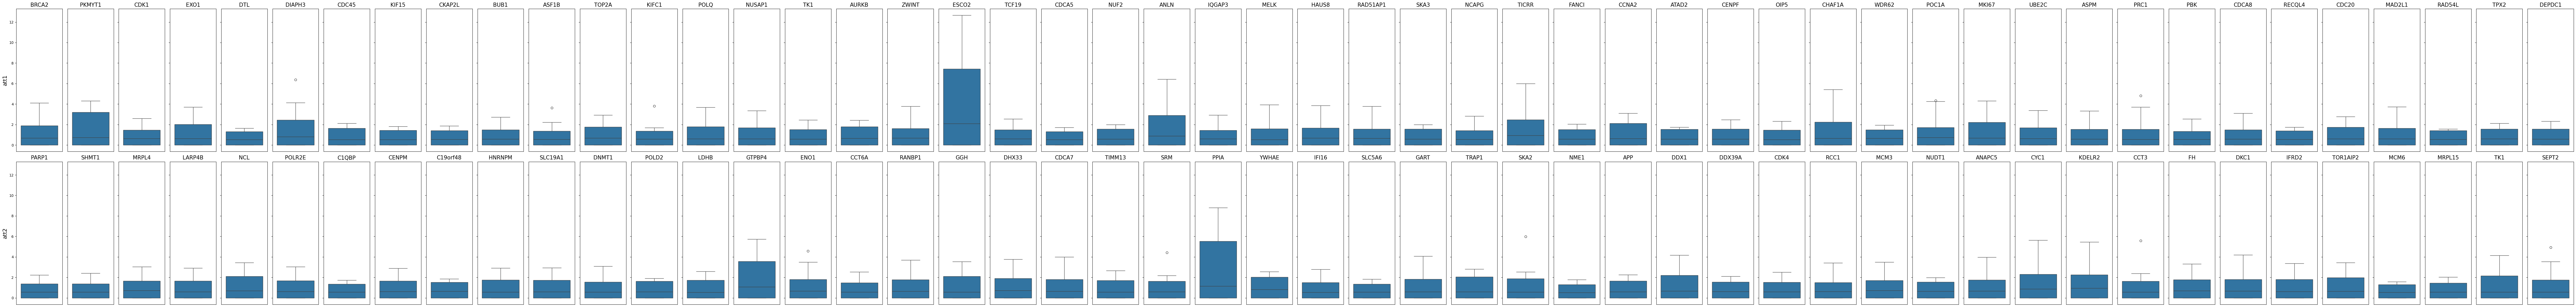

In [58]:
plot_att_boxplot(trans_att_all)